# Day 1.6 — The Same Loop in LangGraph (Optional)
LangGraph represents a loop you already understand as explicit **state**, **nodes**, and
**edges**. It earns its place when a workflow needs branching, checkpoints, or resumability
(Day 3 and Day 5). It is not the agent's intelligence; it organises the loop.

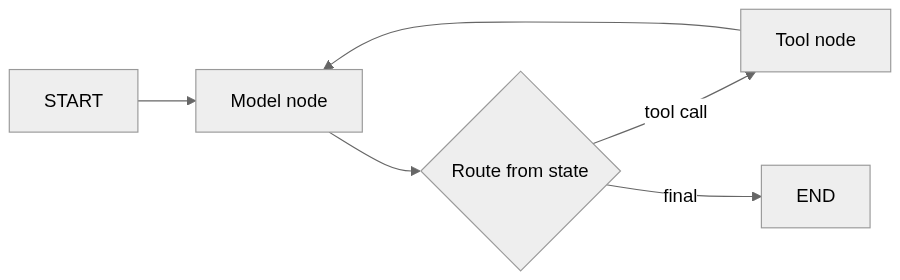

*D05 — model node routes to the tool node on a tool call, back to the model, or to END*

### When is an agent the right design?

Use plain code when the steps are known. Use a hybrid workflow when one bounded judgement
benefits from a model. Use an agent only when the next action cannot be predetermined, the
action set is small, failures are containable, and success can be measured. If those answers are weak, build a workflow.

In [ ]:
%pip install -q langgraph

In [ ]:
try:
    from langgraph.graph import END, START, StateGraph
    from typing import TypedDict
    GRAPH_AVAILABLE = True
except ImportError:
    GRAPH_AVAILABLE = False
    print("LangGraph is not installed; re-run the pip cell above. Skipping this section is fine.")

if GRAPH_AVAILABLE:
    class AgentState(TypedDict):
        messages: list          # the same history our loop kept
        steps: int
        max_steps: int
        status: str

    tool_schemas = [t["schema"] for t in TOOLS.values()]

    def model_node(state):                                     # = "call the model"
        reply = chat(state["messages"], tools=tool_schemas)
        messages = state["messages"] + [assistant_message(reply)]
        return {"messages": messages, "steps": state["steps"] + 1,
                "status": "completed" if not reply["tool_calls"] else "working"}

    def tool_node(state):                                      # = "validate and execute"
        last = state["messages"][-1]
        results = [{"role": "tool", "tool_call_id": c["id"],
                    "content": execute_tool_call({"id": c["id"], "name": c["function"]["name"],
                                                  "arguments": json.loads(c["function"]["arguments"])}, TOOLS)}
                   for c in last["tool_calls"]]
        return {"messages": state["messages"] + results}

    def route(state):                                          # = the if/else in our loop
        if state["status"] == "completed":
            return END
        return "tools" if state["steps"] < state["max_steps"] else END

    builder = StateGraph(AgentState)
    builder.add_node("model", model_node)
    builder.add_node("tools", tool_node)
    builder.add_edge(START, "model")
    builder.add_conditional_edges("model", route, {"tools": "tools", END: END})
    builder.add_edge("tools", "model")
    graph = builder.compile()

    final_state = graph.invoke({"messages": [{"role": "system", "content": SYSTEM_PROMPT},
                                             {"role": "user", "content": "What is 12 * 9?"}],
                                "steps": 0, "max_steps": 5, "status": "working"})
    print("status :", final_state["status"], "| steps:", final_state["steps"])
    print("answer :", final_state["messages"][-1]["content"][:200])
    print("roles  :", [m["role"] for m in final_state["messages"]])

### Checkpoint

**1. Map each part of LangGraph to a line in your `run_agent`.**

<details><summary>Show answer</summary>

`model_node` = the `model(...)` call plus appending the assistant message; `tool_node` = the `execute_tool_call` loop; `route` = the `if not reply['tool_calls']` and the step-limit check; the graph's edges = the `for` loop returning to the model.

</details>

**2. What did LangGraph *not* provide?**

<details><summary>Show answer</summary>

Tools, argument validation, the step limit's value, evaluation, and policy. Those stay yours. The framework only organises the control flow.

</details>

### Recap

- **Limitation seen:** a hand-written loop is hard to extend with branching, pausing, or resuming.
- **Layer added:** the same loop as explicit state, nodes, and conditional edges.
- **Evidence:** the graph reached the same answer through the same message roles.